In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
transactions = pd.read_csv('../Data/transactions_cleaned.csv')

In [3]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   transaction id         250000 non-null  object
 1   timestamp              250000 non-null  object
 2   transaction type       250000 non-null  object
 3   merchant_category      250000 non-null  object
 4   amount (INR)           250000 non-null  int64 
 5   transaction_status     250000 non-null  object
 6   sender_age_group       250000 non-null  object
 7   receiver_age_group     250000 non-null  object
 8   sender_state           250000 non-null  object
 9   sender_bank            250000 non-null  object
 10  receiver_bank          250000 non-null  object
 11  device_type            250000 non-null  object
 12  network_type           250000 non-null  object
 13  fraud_flag             250000 non-null  int64 
 14  hour_of_day            250000 non-null  int64 
 15  

In [4]:
transactions.head(10)

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,...,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend,Month,Time_period,amount_category,Same_Bank_Transaction
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,...,Android,4G,0,15,Tuesday,0,October,Afternoon,Medium,No
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,...,iOS,4G,0,6,Thursday,0,April,Morning,Medium,No
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,...,Android,4G,0,13,Tuesday,0,April,Afternoon,Low,No
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,...,Android,5G,0,10,Sunday,1,January,Morning,High,No
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,...,iOS,WiFi,0,19,Tuesday,0,January,Evening,Medium,No
5,TXN0000000006,2024-10-07 22:32:07,P2P,Food,91,SUCCESS,36-45,18-25,Karnataka,IndusInd,...,Android,3G,0,22,Monday,0,October,Night,Low,No
6,TXN0000000007,2024-02-08 10:25:57,P2P,Other,314,SUCCESS,36-45,18-25,Telangana,HDFC,...,Android,4G,0,10,Thursday,0,February,Morning,Low,No
7,TXN0000000008,2024-10-27 18:47:02,P2P,Utilities,264,SUCCESS,46-55,36-45,Maharashtra,Yes Bank,...,Android,5G,0,18,Sunday,1,October,Evening,Low,No
8,TXN0000000009,2024-11-21 09:39:16,P2P,Other,887,SUCCESS,46-55,36-45,Maharashtra,Kotak,...,Android,4G,0,9,Thursday,0,November,Morning,Medium,No
9,TXN0000000010,2024-11-11 15:58:56,P2M,Grocery,3260,SUCCESS,46-55,18-25,Delhi,SBI,...,Android,4G,0,15,Monday,0,November,Afternoon,High,No


# EDA using Univariate Analysis

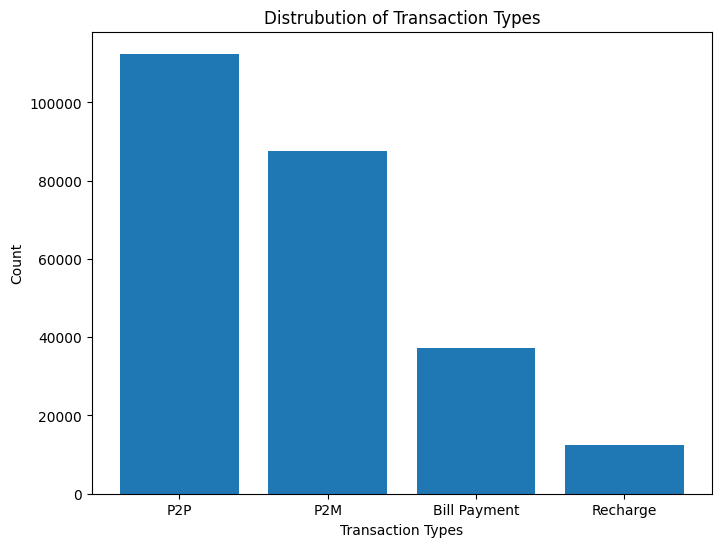

transaction type
P2P             112445
P2M              87660
Bill Payment     37368
Recharge         12527
Name: count, dtype: int64


In [5]:
# Transaction Types
Transaction_type = transactions['transaction type'].value_counts()

plt.figure(figsize=(8,6))
plt.bar(Transaction_type.index,Transaction_type.values)
plt.title("Distrubution of Transaction Types")
plt.xlabel("Transaction Types")
plt.ylabel("Count")
plt.show()

print(Transaction_type)

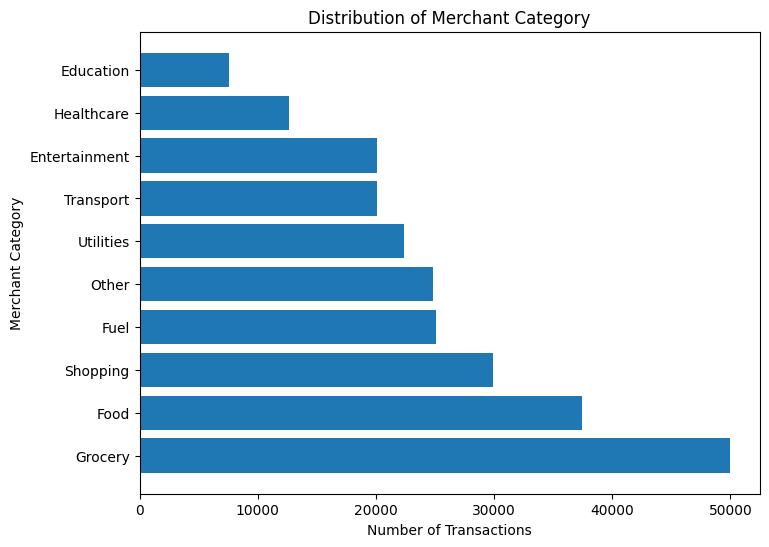

merchant_category
Grocery          49966
Food             37464
Shopping         29872
Fuel             25063
Other            24828
Utilities        22338
Transport        20105
Entertainment    20103
Healthcare       12663
Education         7598
Name: count, dtype: int64


In [6]:
# Merchant Category
merchant_category = transactions['merchant_category'].value_counts()

plt.figure(figsize = (8,6))
plt.barh(merchant_category.index,merchant_category)
plt.title("Distribution of Merchant Category")
plt.xlabel("Number of Transactions")
plt.ylabel("Merchant Category")
plt.show()

print(merchant_category)

<Axes: xlabel='count', ylabel='transaction_status'>

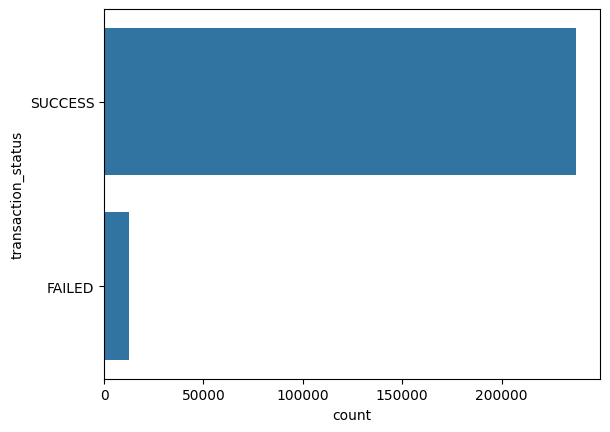

In [7]:
sns.countplot(transactions['transaction_status'])

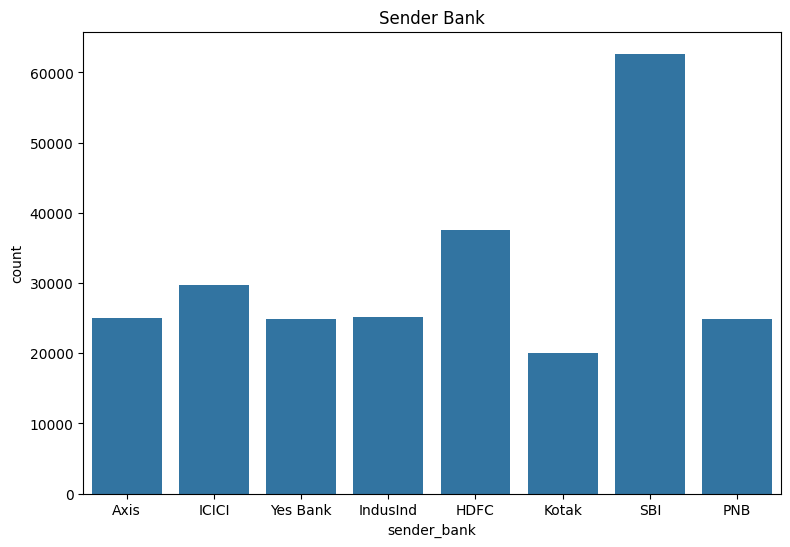

In [8]:
plt.figure(figsize=(9,6))
sns.countplot(data=transactions,x='sender_bank')
plt.title("Sender Bank")
plt.show()

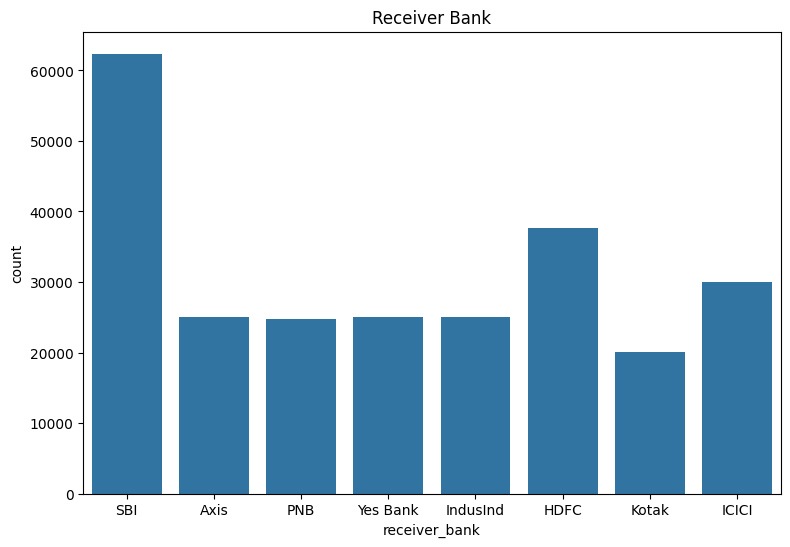

In [9]:
plt.figure(figsize=(9,6))
sns.countplot(data=transactions,x='receiver_bank')
plt.title("Receiver Bank")
plt.show()

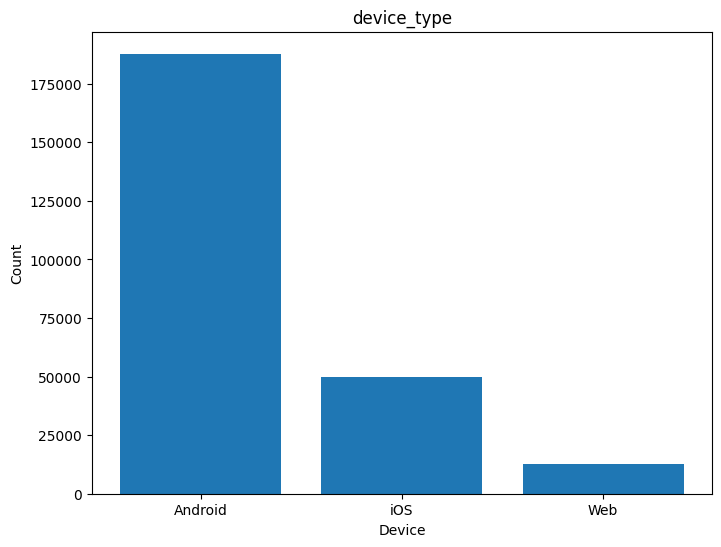

In [10]:
# Device Type
device_type= transactions['device_type'].value_counts()
plt.figure(figsize=(8,6))
plt.bar(device_type.index,device_type)
plt.xlabel("Device")
plt.ylabel("Count")
plt.title("device_type")
plt.show()

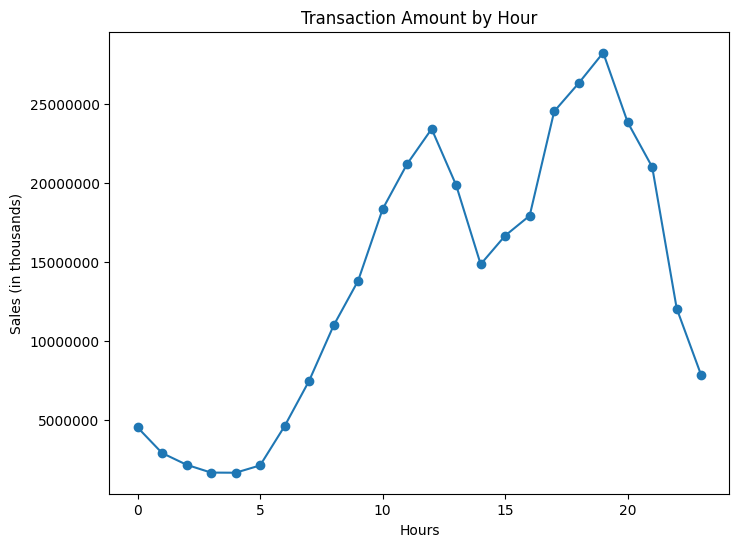

In [11]:
# hour_of_day
hoyrly_sales = transactions.groupby('hour_of_day')['amount (INR)'].sum()

plt.figure(figsize=(8,6))
plt.plot(hoyrly_sales.index,hoyrly_sales.values,marker = 'o',linestyle = '-')
plt.ticklabel_format(style='plain', axis='y')
plt.title("Transaction Amount by Hour")
plt.xlabel("Hours")
plt.ylabel("Sales (in thousands)")
plt.show()

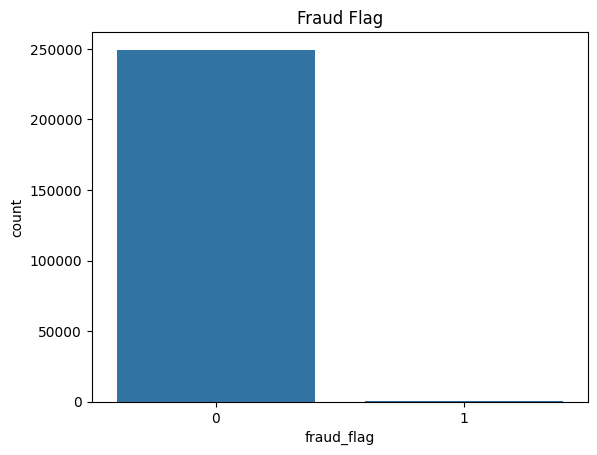

fraud_flag
0    249520
1       480
Name: count, dtype: int64


In [12]:
sns.countplot(data=transactions,x='fraud_flag')
plt.title("Fraud Flag")
plt.show()
fraude_flag = transactions['fraud_flag'].value_counts()
print(fraude_flag)

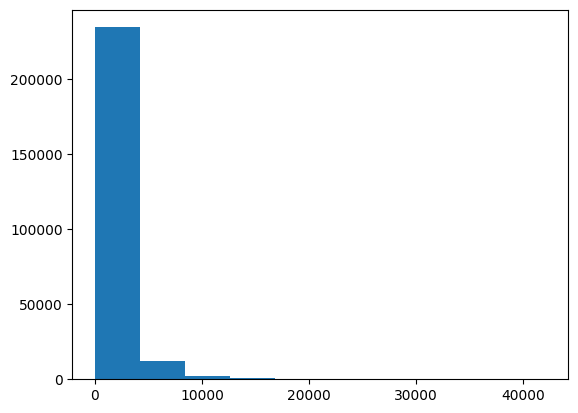

<Axes: xlabel='amount (INR)'>

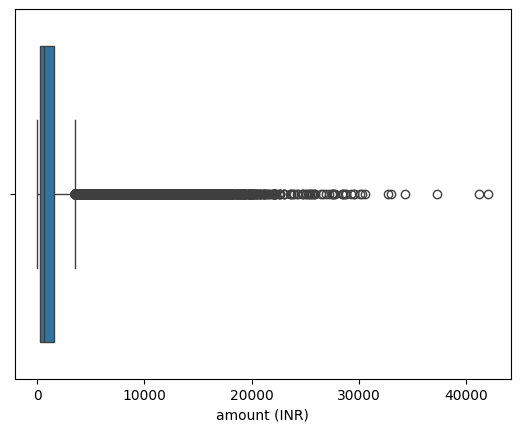

In [13]:
plt.hist(transactions['amount (INR)'])
plt.show()
sns.boxplot(x=transactions['amount (INR)'])

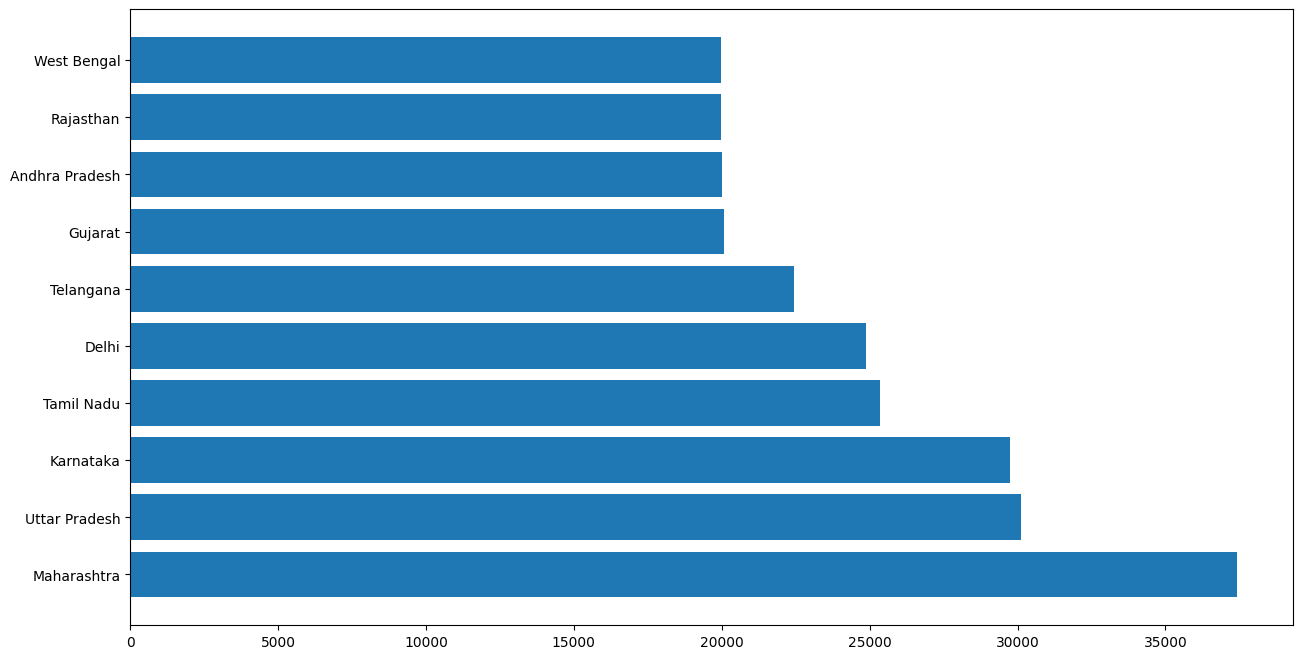

In [14]:
plt.figure(figsize=(15,8))
sender_state = transactions['sender_state'].value_counts()
plt.barh(sender_state.index,sender_state.values)
plt.show()

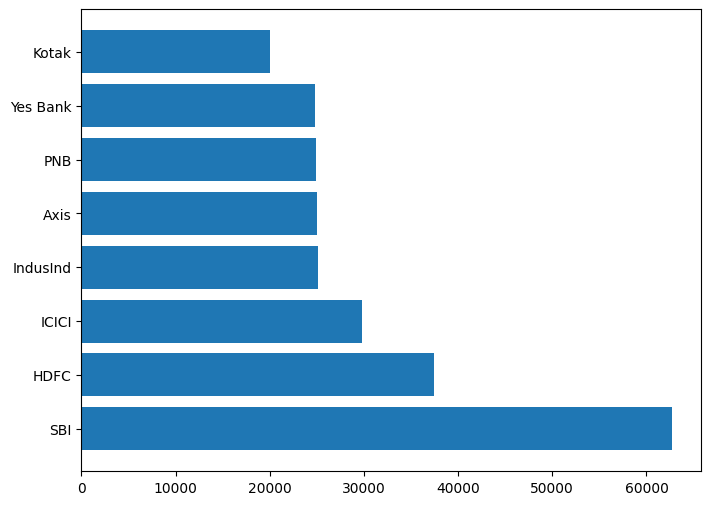

In [15]:
plt.figure(figsize=(8,6))
sender_bank = transactions['sender_bank'].value_counts()
plt.barh(sender_bank.index,sender_bank.values)
plt.show()

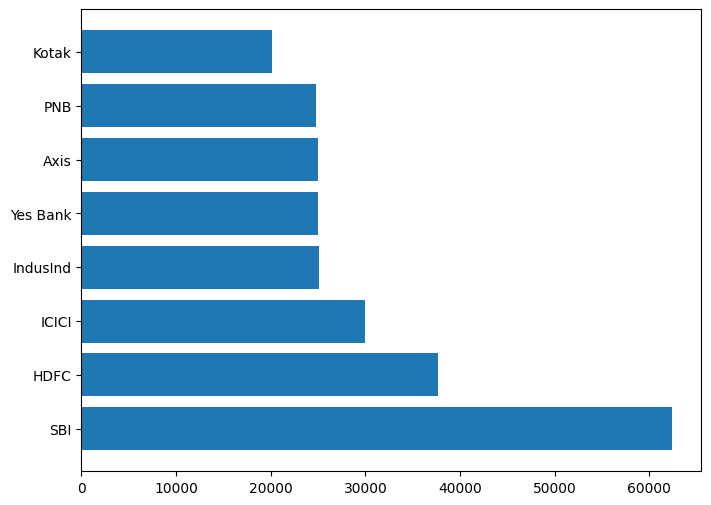

In [16]:
plt.figure(figsize=(8,6))
receiver_bank = transactions['receiver_bank'].value_counts()
plt.barh(receiver_bank.index,receiver_bank.values)
plt.show()

# EDA using Bivariate Analysis

In [17]:
transactions.groupby('transaction type')['amount (INR)'].sum()

transaction type
Bill Payment     48895743
P2M             115717567
P2P             147154648
Recharge         16171051
Name: amount (INR), dtype: int64

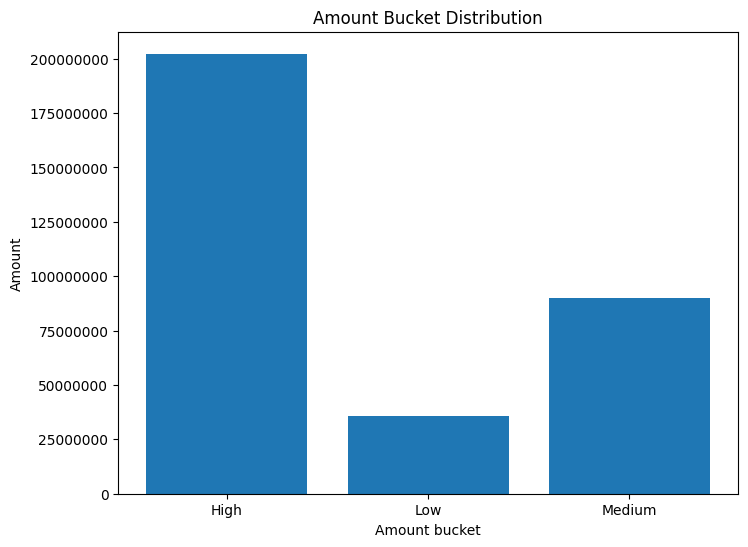

amount_category
High      202265869
Low        35683865
Medium     89989275
Name: amount (INR), dtype: int64


In [18]:
amount_bucket = transactions.groupby("amount_category")['amount (INR)'].sum()

plt.figure(figsize = (8,6))
plt.bar(amount_bucket.index,amount_bucket.values)
plt.ticklabel_format(style = "plain",axis = "y")
plt.title("Amount Bucket Distribution")
plt.xlabel("Amount bucket")
plt.ylabel("Amount")
plt.show()
print(amount_bucket)

### Observation

- High-value transactions contribute the largest share of the total transaction value, followed by medium-value transactions.
- Low-value transactions account for the smallest portion of the overall transaction amount.
- Although high-value transactions may not be the most frequent, they dominate the overall transaction volume in monetary terms.

### Business Insight

- High-value transactions should be prioritized for fraud monitoring since they pose the greatest financial risk.
- Financial institutions can apply additional verification measures for high-value transactions to minimize potential monetary losses.
- Monitoring transaction value by amount bucket enables better allocation of fraud prevention resources.

In [19]:
transactions.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,...,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend,Month,Time_period,amount_category,Same_Bank_Transaction
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,...,Android,4G,0,15,Tuesday,0,October,Afternoon,Medium,No
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,...,iOS,4G,0,6,Thursday,0,April,Morning,Medium,No
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,...,Android,4G,0,13,Tuesday,0,April,Afternoon,Low,No
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,...,Android,5G,0,10,Sunday,1,January,Morning,High,No
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,...,iOS,WiFi,0,19,Tuesday,0,January,Evening,Medium,No


fraud_flag             0    1
transaction type             
Bill Payment       37291   77
P2M                87493  167
P2P               112239  206
Recharge           12497   30


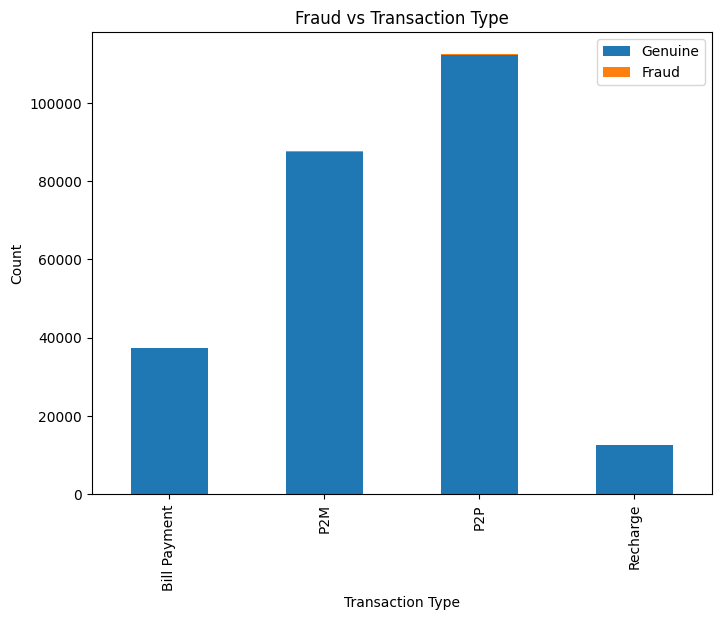

In [20]:
# Fraud vs Transaction Type
fraud_transactions = transactions.groupby('transaction type')['fraud_flag'].value_counts().unstack()
print(fraud_transactions)

fraud_transactions.plot(kind='bar',stacked=True,figsize=(8,6))
plt.title('Fraud vs Transaction Type')
plt.legend(['Genuine', 'Fraud'])
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

### Observation

- P2P transactions recorded the highest number of both genuine and fraudulent transactions among all transaction types.
- Recharge transactions contributed the lowest transaction volume as well as the fewest fraudulent transactions.
- Fraudulent transactions represent only a small fraction of the total transactions across every transaction type.

### Business Insight

- Since P2P transactions have the highest transaction volume, they should receive continuous fraud monitoring despite the relatively low fraud count.
- Fraud detection models should prioritize high-volume transaction types because even a low fraud rate can result in significant financial losses.
- Transaction-type-based monitoring rules can improve fraud detection efficiency.

fraud_flag             0   1
merchant_category           
Education           7582  16
Entertainment      20063  40
Food               37391  73
Fuel               25015  48
Grocery            49872  94
Healthcare         12642  21
Other              24778  50
Shopping           29810  62
Transport          20062  43
Utilities          22305  33


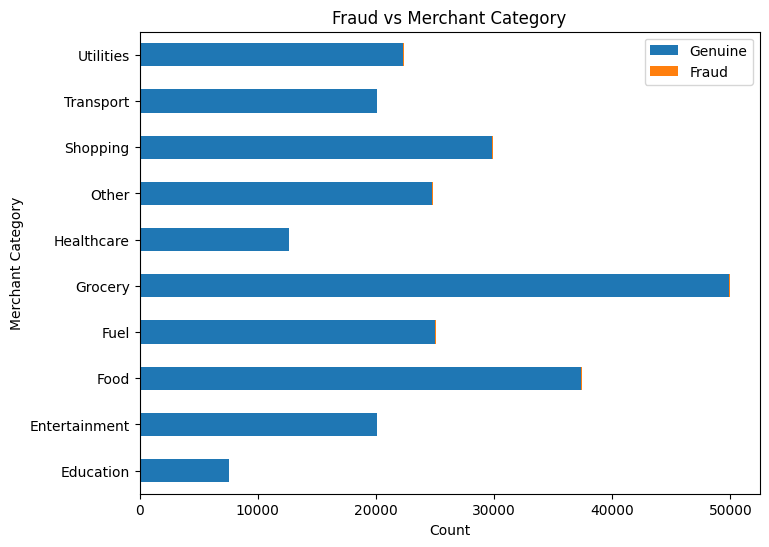

In [21]:
# Fraud vs Merchant Category
fraud_merchant = transactions.groupby('merchant_category')['fraud_flag'].value_counts().unstack()
print(fraud_merchant)

fraud_merchant.plot(kind='barh',stacked = True,figsize = (8,6))
plt.legend(['Genuine','Fraud'])
plt.title('Fraud vs Merchant Category')
plt.ylabel('Merchant Category')
plt.xlabel('Count')
plt.show()

### Observation

- Grocery transactions recorded the highest transaction volume among all merchant categories.
- Education and Healthcare recorded comparatively lower transaction volumes.
- Fraudulent transactions remain relatively low across all merchant categories, although Grocery, Food, and Shopping show comparatively higher fraud counts due to their larger transaction volumes.

### Business Insight

- High-volume merchant categories should receive greater fraud monitoring attention because they process the majority of customer transactions.
- Merchant-category-based fraud rules can help payment providers identify suspicious transaction patterns more effectively.
- Continuous monitoring of frequently used merchant categories can reduce operational fraud risk.

fraud_flag               0    1
transaction_status             
FAILED               12355   21
SUCCESS             237165  459


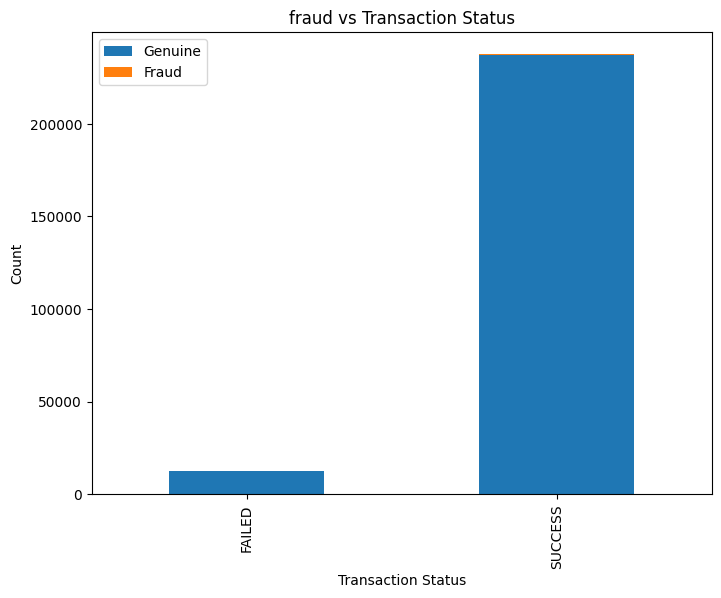

In [22]:
# Fraud vs Transaction Status
fraud_tran_status = transactions.groupby('transaction_status')['fraud_flag'].value_counts().unstack()
print(fraud_tran_status)

fraud_tran_status.plot(kind = 'bar',stacked=True,figsize=(8,6))
plt.title("fraud vs Transaction Status")
plt.legend(['Genuine','Fraud'])
plt.xlabel('Transaction Status')
plt.ylabel('Count')
plt.show()

### Observation

- The majority of transactions were completed successfully.
- Failed transactions account for only a small proportion of the overall transaction volume.
- Fraudulent transactions were observed primarily among successful transactions due to their significantly larger transaction volume.

### Business Insight

- Successful transactions should be continuously monitored because they represent the majority of payment activity.
- Fraud detection should occur before transaction completion to reduce financial losses.
- Monitoring successful transactions can improve real-time fraud prevention strategies.

fraud_flag       0    1
sender_bank            
Axis         24993   49
HDFC         37423   62
ICICI        29703   66
IndusInd     25121   52
Kotak        19982   50
PNB          24894   52
SBI          62584  109
Yes Bank     24820   40


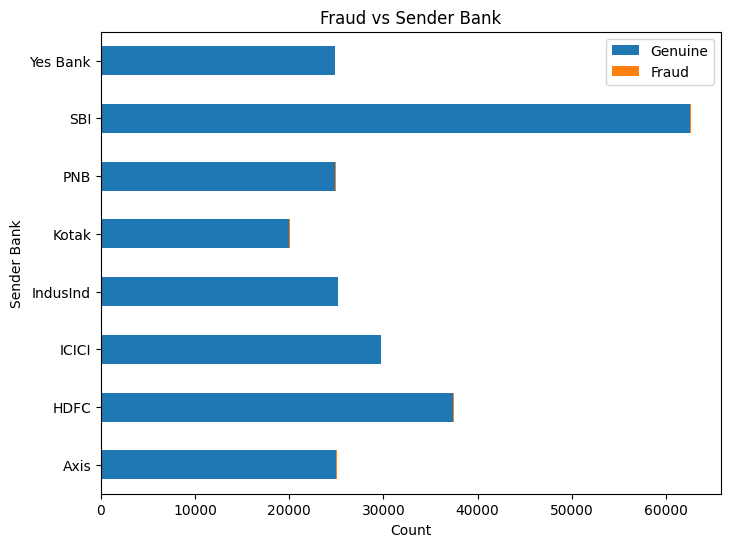

In [23]:
# Fraud vs Sender Bank
fraud_senderbank = transactions.groupby('sender_bank')['fraud_flag'].value_counts().unstack()
print(fraud_senderbank)

fraud_senderbank.plot(kind = 'barh',stacked=True,figsize=(8,6))
plt.title("Fraud vs Sender Bank")
plt.legend(['Genuine','Fraud'])
plt.ylabel("Sender Bank")
plt.xlabel('Count')
plt.show()

### Observation

- SBI processed the highest number of transactions among all sender banks.
- Fraudulent transactions remain relatively low across all banks.
- Fraud counts generally increase with transaction volume rather than being concentrated within a single sender bank.

### Business Insight

- Banks processing higher transaction volumes should implement stronger fraud monitoring mechanisms.
- Fraud prevention strategies should consider transaction volume alongside fraud counts when allocating monitoring resources.
- Collaboration between payment providers and high-volume banks can improve fraud detection performance.

fraud_flag         0    1
receiver_bank            
Axis           24951   41
HDFC           37578   73
ICICI          29887   57
IndusInd       25034   52
Kotak          20097   41
PNB            24753   49
SBI            62262  116
Yes Bank       24958   51


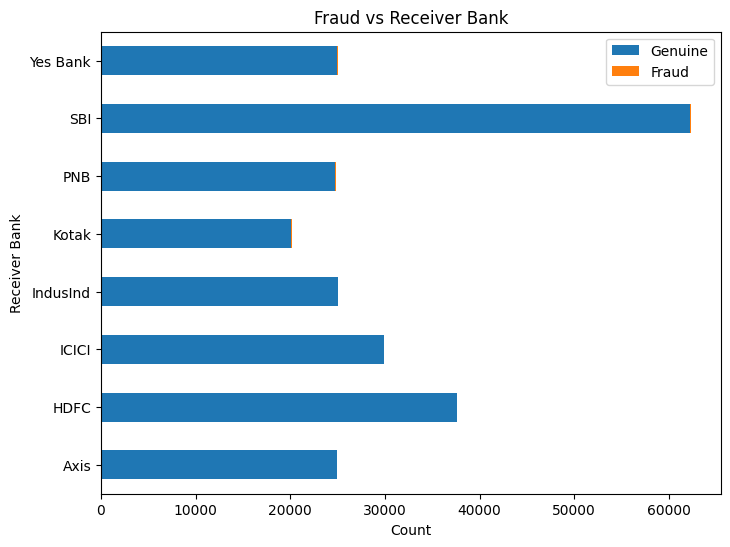

In [24]:
# Fraud vs Receiver Bank
fraud_receiverbank = transactions.groupby('receiver_bank')['fraud_flag'].value_counts().unstack()
print(fraud_receiverbank)

fraud_receiverbank.plot(kind = 'barh',stacked=True,figsize=(8,6))
plt.title("Fraud vs Receiver Bank")
plt.legend(['Genuine','Fraud'])
plt.ylabel("Receiver Bank")
plt.xlabel('Count')
plt.show()

### Observation

- SBI also received the highest number of transactions among receiver banks.
- Fraudulent transactions are distributed across all receiver banks but remain relatively uncommon.
- No receiver bank demonstrates an unusually high concentration of fraudulent transactions based on transaction volume.

### Business Insight

- Receiver banks handling large transaction volumes should strengthen fraud detection and transaction verification processes.
- Cross-bank fraud monitoring can improve the identification of suspicious fund transfers.
- Continuous monitoring across major receiver banks can reduce financial exposure.

fraud_flag        0    1
device_type             
Android      187413  364
Web           12584   26
iOS           49523   90


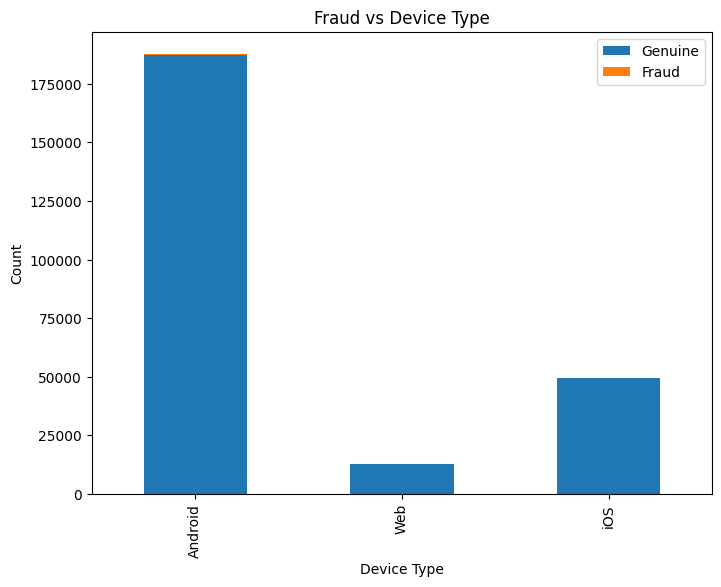

In [25]:
# Fraud vs Device Type
fraud_device_type = transactions.groupby('device_type')['fraud_flag'].value_counts().unstack()
print(fraud_device_type)

fraud_device_type.plot(kind = 'bar',stacked=True,figsize=(8,6))
plt.title("Fraud vs Device Type")
plt.legend(['Genuine','Fraud'])
plt.xlabel("Device Type")
plt.ylabel('Count')
plt.show()

### Observation

- Android devices account for the majority of both genuine and fraudulent transactions.
- iOS contributes a moderate share of transactions, while Web devices account for the smallest transaction volume.
- Fraud distribution generally follows overall device usage patterns.

### Business Insight

- Android transactions should receive greater fraud monitoring due to their high transaction volume.
- Device-based authentication mechanisms such as device fingerprinting can enhance fraud detection.
- Device analytics can provide valuable features for fraud prediction models.

fraud_flag       0   1
hour_of_day           
0             3380   8
1             2238   6
2             1682   3
3             1310   4
4             1246   1
5             1741   1
6             3496   5
7             5617  13
8             8331  18
9            10430  20
10           13884  20
11           16301  27
12           17486  30
13           15013  25
14           11451  21
15           12592  32
16           13961  31
17           18303  37
18           20033  31
19           21189  43
20           18469  37
21           16218  35
22            9341  23
23            5808   9


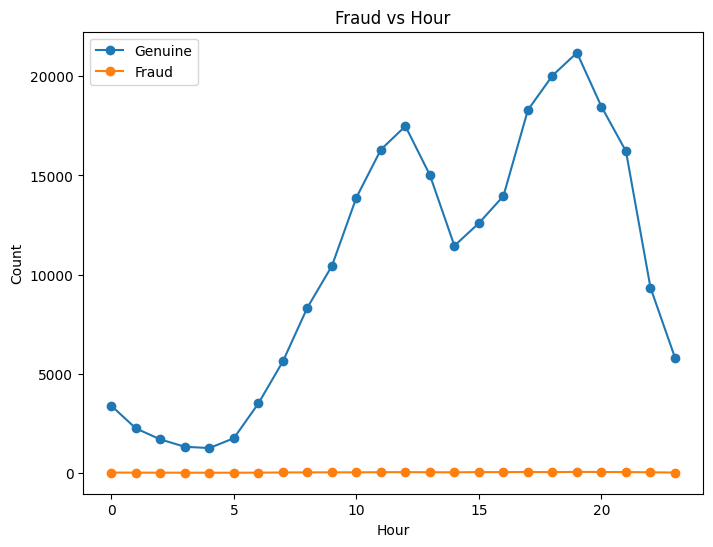

In [26]:
# Fraud vs Hour
fraud_hour = transactions.groupby('hour_of_day')['fraud_flag'].value_counts().unstack()
print(fraud_hour)

fraud_hour.plot(kind = 'line',stacked=False,figsize=(8,6),marker="o")
plt.title("Fraud vs Hour")
plt.legend(['Genuine','Fraud'])
plt.xlabel("Hour")
plt.ylabel('Count')
plt.show()

### Observation

- Transaction activity increases steadily during the morning and peaks during the evening hours.
- The highest transaction volume occurs between approximately 18:00 and 20:00.
- Fraudulent transaction counts remain comparatively low throughout the day but generally follow overall transaction activity.

### Business Insight

- Peak transaction hours require increased fraud monitoring because higher transaction volumes increase operational risk.
- Fraud detection systems should be optimized to handle increased transaction loads during evening hours.
- Dynamic fraud detection thresholds can improve monitoring efficiency during peak business periods.

fraud_flag       0   1
day_of_week           
Friday       35435  61
Monday       36424  71
Saturday     35266  68
Sunday       35928  75
Thursday     35360  72
Tuesday      35482  58
Wednesday    35625  75


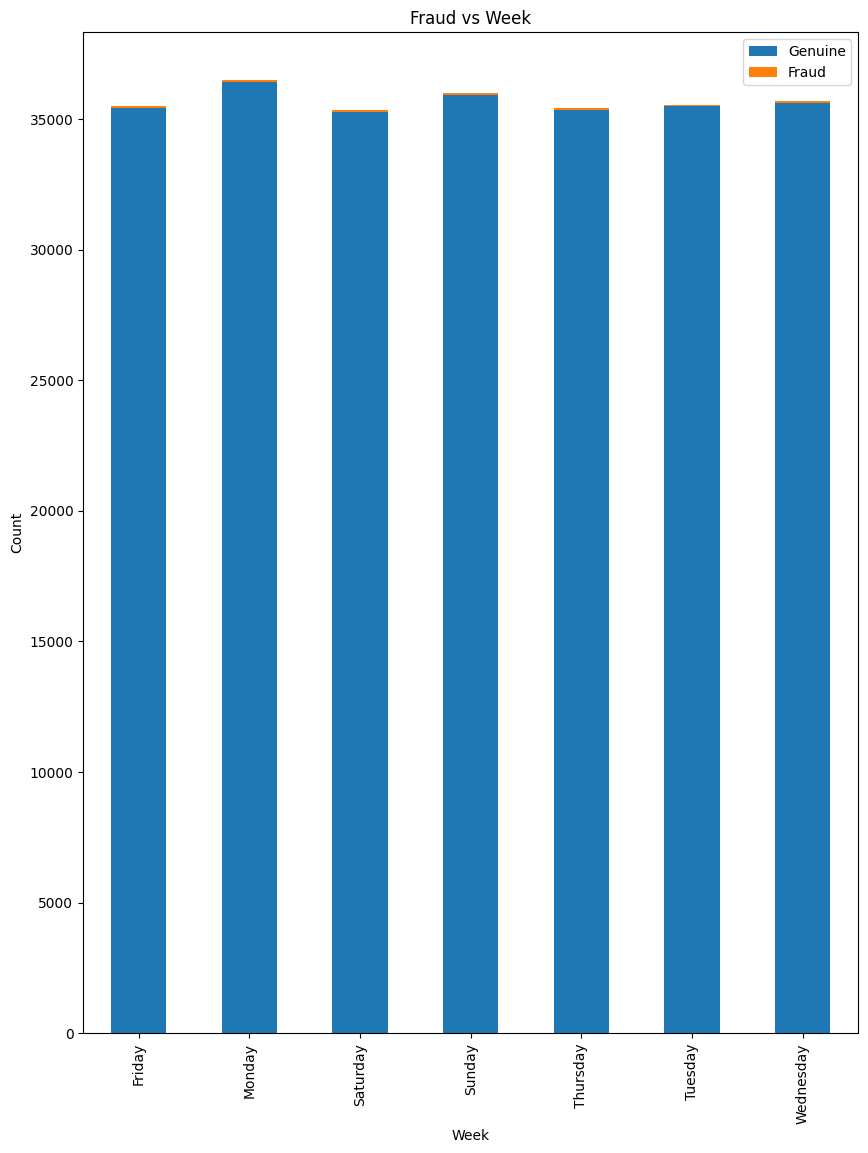

In [27]:
# Fraud vs Day of Week
fraud_week = transactions.groupby('day_of_week')['fraud_flag'].value_counts().unstack()
print(fraud_week)

fraud_week.plot(kind = 'bar',stacked=True,figsize=(10,13))
plt.title("Fraud vs Week")
plt.legend(['Genuine','Fraud'])
plt.xlabel("Week")
plt.ylabel('Count')
plt.show()

fraud_flag      0   1
Month                
April       20503  33
August      21198  33
December    20598  38
February    19725  34
January     21171  50
July        21155  52
June        20598  30
March       21187  47
May         21296  37
November    20327  39
October     21207  45
September   20555  42


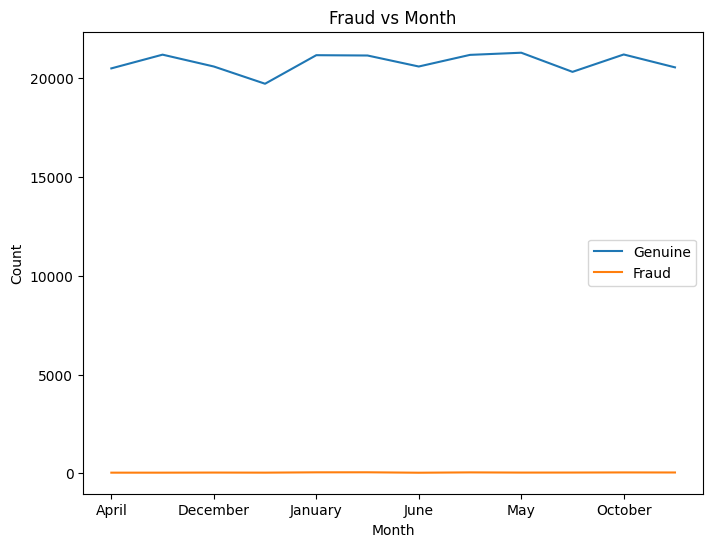

In [28]:
# Fraud vs Month
fraud_month = transactions.groupby('Month')['fraud_flag'].value_counts().unstack()
print(fraud_month)

fraud_month.plot(kind = 'line',stacked=False,figsize=(8,6))
plt.title("Fraud vs Month")
plt.legend(['Genuine','Fraud'])
plt.xlabel("Month")
plt.ylabel('Count')
plt.show()

fraud_flag            0    1
amount_category             
High              49053  102
Low              121177  235
Medium            79290  143


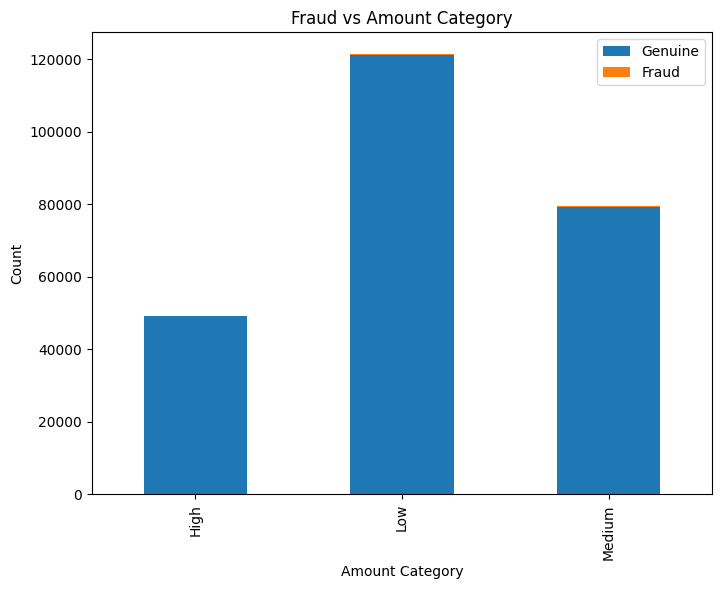

In [29]:
# Fraud vs Amount Category
fraud_amount_category = transactions.groupby('amount_category')['fraud_flag'].value_counts().unstack()
print(fraud_amount_category)

fraud_amount_category.plot(kind = 'bar',stacked=True,figsize=(8,6))
plt.title("Fraud vs Amount Category")
plt.legend(['Genuine','Fraud'])
plt.xlabel("Amount Category")
plt.ylabel('Count')
plt.show()